# AAI 501 Final Team Project  
## Intelligent Predictive Maintenance for NASA C-MAPSS Turbofan Engines

**Objective:** Predict Remaining Useful Life (RUL), compare classical ML and recurrent neural networks, and convert the selected model's predictions into a capacity-constrained maintenance queue.


## Executive summary

This notebook presents the complete end-to-end workflow used for the final project:

1. Load FD001 and create capped Remaining Useful Life (RUL) labels.
2. Create one engine-level train/validation split and reuse it throughout model development.
3. Perform degradation-focused EDA.
4. Select sensors using the training engines only and engineer backward-looking temporal features for tabular models.
5. Compare baseline models and tuned XGBoost.
6. Compare LSTM and GRU models using 30-cycle sensor sequences.
7. Select the recurrent model using validation performance, then retrain on all 100 training engines.
8. Evaluate the finalized recurrent models on the official FD001 test engines.
9. Convert the validation-selected model's RUL predictions into a PEAS-based maintenance decision-support queue.

The notebook intentionally separates **model development** from **final test evaluation** so the official test set does not influence model selection.


# 1. Setup, paths, and reproducibility

In [1]:
from pathlib import Path
import copy
import json
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)

# Reproducibility and modeling constants used across the notebook.
RANDOM_STATE = 42
RUL_CAP = 125
SEQUENCE_LENGTH = 30
BATCH_SIZE = 256
MAX_EPOCHS = 60
PATIENCE = 8

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)


In [ ]:
    def find_project_root() -> Path:
        """Locate the repository root without relying on a machine-specific path."""

        current = Path.cwd().resolve()

        # README.md and the expected project folders act as stable repository markers.
        for candidate in [current, *current.parents]:
            if (
                (candidate / "README.md").is_file()
                and (candidate / "data").is_dir()
                and (candidate / "notebooks").is_dir()
            ):
                return candidate

        raise FileNotFoundError(
            "Could not locate the project root. Run the notebook from inside "
            "the intelligent-predictive-maintenance repository."
        )


    PROJECT_ROOT = find_project_root()

    # Input and generated-data locations.
    DATA_DIR = PROJECT_ROOT / "data"
    RAW_DIR = DATA_DIR / "raw" / "CMAPSSData"
    PROCESSED_DIR = DATA_DIR / "processed"
    PREDICTIONS_DIR = DATA_DIR / "predictions"

    # Model artifacts are kept separately from presentation/report outputs.
    MODELS_DIR = PROJECT_ROOT / "models"
    OUTPUTS_DIR = PROJECT_ROOT / "outputs"
    FIGURES_DIR = OUTPUTS_DIR / "figures"
    REPORTS_DIR = OUTPUTS_DIR / "reports"

    # Generated folders are created automatically for a clean first run.
    for directory in [
        PROCESSED_DIR,
        PREDICTIONS_DIR,
        MODELS_DIR,
        FIGURES_DIR,
        REPORTS_DIR,
    ]:
        directory.mkdir(parents=True, exist_ok=True)

    # Fail early with a clear message if the required FD001 files are missing.
    required_files = [
        RAW_DIR / "train_FD001.txt",
        RAW_DIR / "test_FD001.txt",
        RAW_DIR / "RUL_FD001.txt",
    ]
    missing_files = [path for path in required_files if not path.is_file()]

    if missing_files:
        missing_text = "\n".join(f"  - {path}" for path in missing_files)
        raise FileNotFoundError(
            "Required FD001 files are missing:\n"
            f"{missing_text}"
        )


    def save_current_figure(filename: str) -> None:
        """Save the active Matplotlib figure to outputs/figures."""
        plt.savefig(
            FIGURES_DIR / filename,
            dpi=200,
            bbox_inches="tight",
        )


    print("PROJECT_ROOT :", PROJECT_ROOT)
    print("RAW_DIR      :", RAW_DIR)
    print("PROCESSED_DIR:", PROCESSED_DIR)
    print("MODELS_DIR   :", MODELS_DIR)
    print("OUTPUTS_DIR  :", OUTPUTS_DIR)


PROJECT_ROOT : /Users/sudhakaransrinivasan/Documents/GitHub/intelligent-predictive-maintenance
RAW_DIR      : /Users/sudhakaransrinivasan/Documents/GitHub/intelligent-predictive-maintenance/data/raw/CMAPSSData
PROCESSED_DIR: /Users/sudhakaransrinivasan/Documents/GitHub/intelligent-predictive-maintenance/data/processed
MODELS_DIR   : /Users/sudhakaransrinivasan/Documents/GitHub/intelligent-predictive-maintenance/models
OUTPUTS_DIR  : /Users/sudhakaransrinivasan/Documents/GitHub/intelligent-predictive-maintenance/outputs


# 2. Load FD001 and create the RUL target

In [3]:
COLUMNS = (
    ["unit_id", "cycle", "setting_1", "setting_2", "setting_3"]
    + [f"sensor_{i}" for i in range(1, 22)]
)


def read_cmapss_file(path: Path) -> pd.DataFrame:
    """Read a C-MAPSS train/test file using the published FD001 column layout."""
    return pd.read_csv(
        path,
        sep=r"\s+",
        header=None,
        names=COLUMNS,
    )


train_raw = read_cmapss_file(RAW_DIR / "train_FD001.txt")
test_raw = read_cmapss_file(RAW_DIR / "test_FD001.txt")

# The RUL file contains one final-life target for each test engine.
test_rul = pd.read_csv(
    RAW_DIR / "RUL_FD001.txt",
    sep=r"\s+",
    header=None,
    names=["actual_rul"],
)
test_rul.insert(0, "unit_id", np.arange(1, len(test_rul) + 1))

print("Train shape:", train_raw.shape)
print("Test shape:", test_raw.shape)
print("Training engines:", train_raw["unit_id"].nunique())
print("Test engines:", test_raw["unit_id"].nunique())
display(train_raw.head())


Train shape: (20631, 26)
Test shape: (13096, 26)
Training engines: 100
Test engines: 100


,unit_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [4]:
# Training engines run to failure, so their final observed cycle is known.
max_cycles = (
    train_raw.groupby("unit_id", as_index=False)["cycle"]
    .max()
    .rename(columns={"cycle": "max_cycle"})
)

train = train_raw.merge(max_cycles, on="unit_id", how="left")
train["rul"] = train["max_cycle"] - train["cycle"]
train["rul_capped"] = train["rul"].clip(upper=RUL_CAP)

# The official test truth corresponds to each test engine's final observed cycle.
test_last_truth = test_rul.copy()

assert train["rul"].min() == 0
assert test_last_truth["actual_rul"].notna().all()

# Create the engine-level development split before any target-based feature selection.
# This prevents validation engines from influencing which sensors are engineered.
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_STATE,
)

train_idx_raw, val_idx_raw = next(
    splitter.split(
        train,
        groups=train["unit_id"],
    )
)

train_engine_ids = set(train.iloc[train_idx_raw]["unit_id"].unique())
val_engine_ids = set(train.iloc[val_idx_raw]["unit_id"].unique())

assert train_engine_ids.isdisjoint(val_engine_ids)

# Only this partition is used for target-based sensor selection.
feature_selection_train = train[
    train["unit_id"].isin(train_engine_ids)
].copy()

print("Development training engines:", len(train_engine_ids))
print("Development validation engines:", len(val_engine_ids))

display(
    train[["unit_id", "cycle", "max_cycle", "rul", "rul_capped"]].head()
)


Development training engines: 80
Development validation engines: 20


,unit_id,cycle,max_cycle,rul,rul_capped
0,1,1,192,191,125
1,1,2,192,190,125
2,1,3,192,189,125
3,1,4,192,188,125
4,1,5,192,187,125


### Why cap RUL at 125?

Early in an engine's life, sensor readings usually remain healthy despite a high RUL. As commonly done in the predictive maintenance literature, we cap the RUL at 125 cycles to focus the model on the degradation phase. We retain both rul and rul_capped so the effect of this assumption is transparent.

# 3. Data quality and degradation-focused EDA

In [5]:
quality_summary = pd.DataFrame({
    "dtype": train.dtypes.astype(str),
    "missing": train.isna().sum(),
    "unique": train.nunique(),
    "std": train.std(numeric_only=True),
})

display(quality_summary.head(30))
print("Duplicate rows:", train.duplicated().sum())

,dtype,missing,unique,std
unit_id,int64,0,100,2.922763e+01
cycle,int64,0,362,6.888099e+01
setting_1,float64,0,158,2.187313e-03
setting_2,float64,0,13,2.930621e-04
setting_3,float64,0,1,0.000000e+00
sensor_1,float64,0,1,0.000000e+00
sensor_2,float64,0,310,5.000533e-01
sensor_3,float64,0,3012,6.131150e+00
sensor_4,float64,0,4051,9.000605e+00
sensor_5,float64,0,1,1.776400e-15


Duplicate rows: 0


### Interpretation

The data-quality check confirms whether missing values, duplicates, or near-constant columns could create avoidable modeling problems. In FD001, the main cleanup issue is not missing data but channels with almost no variation, which are removed from the model inputs later.


count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle, dtype: float64


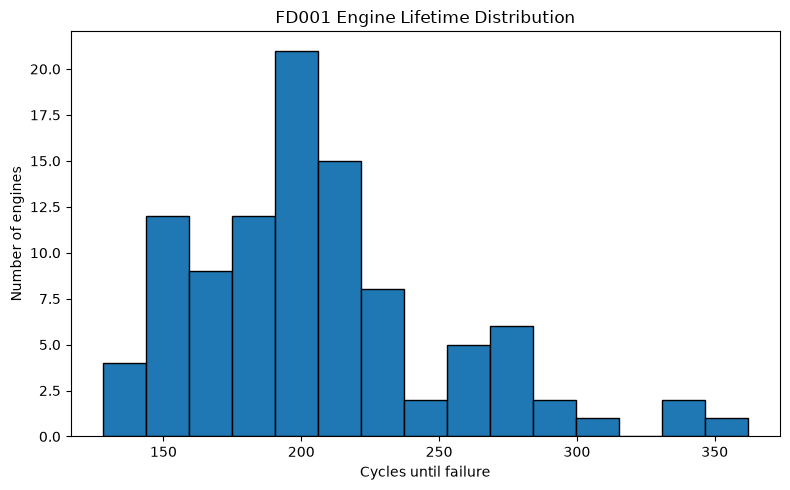

In [6]:
engine_life = train.groupby("unit_id")["cycle"].max()

print(engine_life.describe())

plt.figure(figsize=(8, 5))
plt.hist(engine_life, bins=15, edgecolor="black")
plt.xlabel("Cycles until failure")
plt.ylabel("Number of engines")
plt.title("FD001 Engine Lifetime Distribution")
plt.tight_layout()
save_current_figure("eda_engine_lifetime_distribution.png")
plt.show()


### Interpretation

Engine lifetimes vary across the fleet, so a fixed cycle number does not represent the same life stage for every engine. This is why later trajectory plots normalize each engine's progress from the beginning to the end of its observed life.


In [7]:
sensor_cols = [f"sensor_{i}" for i in range(1, 22)]
setting_cols = ["setting_1", "setting_2", "setting_3"]

# Identify near-constant channels using training engines only.
# These channels add almost no information to the models.
low_variance_cols = [
    column
    for column in setting_cols + sensor_cols
    if feature_selection_train[column].std() < 1e-8
]

selected_sensors = [
    sensor
    for sensor in sensor_cols
    if sensor not in low_variance_cols
]

print("Low-variance columns:", low_variance_cols)
print("Selected sensors:", selected_sensors)


Low-variance columns: ['setting_3', 'sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
Selected sensors: ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


In [8]:
# Correlations used for sensor selection are calculated only on training engines.
correlation_table = pd.DataFrame({
    "corr_with_cycle": feature_selection_train[selected_sensors].corrwith(
        feature_selection_train["cycle"]
    ),
    "corr_with_rul": feature_selection_train[selected_sensors].corrwith(
        feature_selection_train["rul_capped"]
    ),
}).sort_values(
    "corr_with_rul",
    key=lambda values: values.abs(),
    ascending=False,
)

display(correlation_table)


,corr_with_cycle,corr_with_rul
sensor_11,0.643118,-0.771182
sensor_4,0.632483,-0.752307
sensor_12,-0.619636,0.742395
sensor_7,-0.604115,0.727489
sensor_15,0.593734,-0.716662
sensor_21,-0.591648,0.703713
sensor_20,-0.593460,0.702987
sensor_17,0.572665,-0.677277
sensor_2,0.558638,-0.675215
sensor_3,0.551198,-0.652131


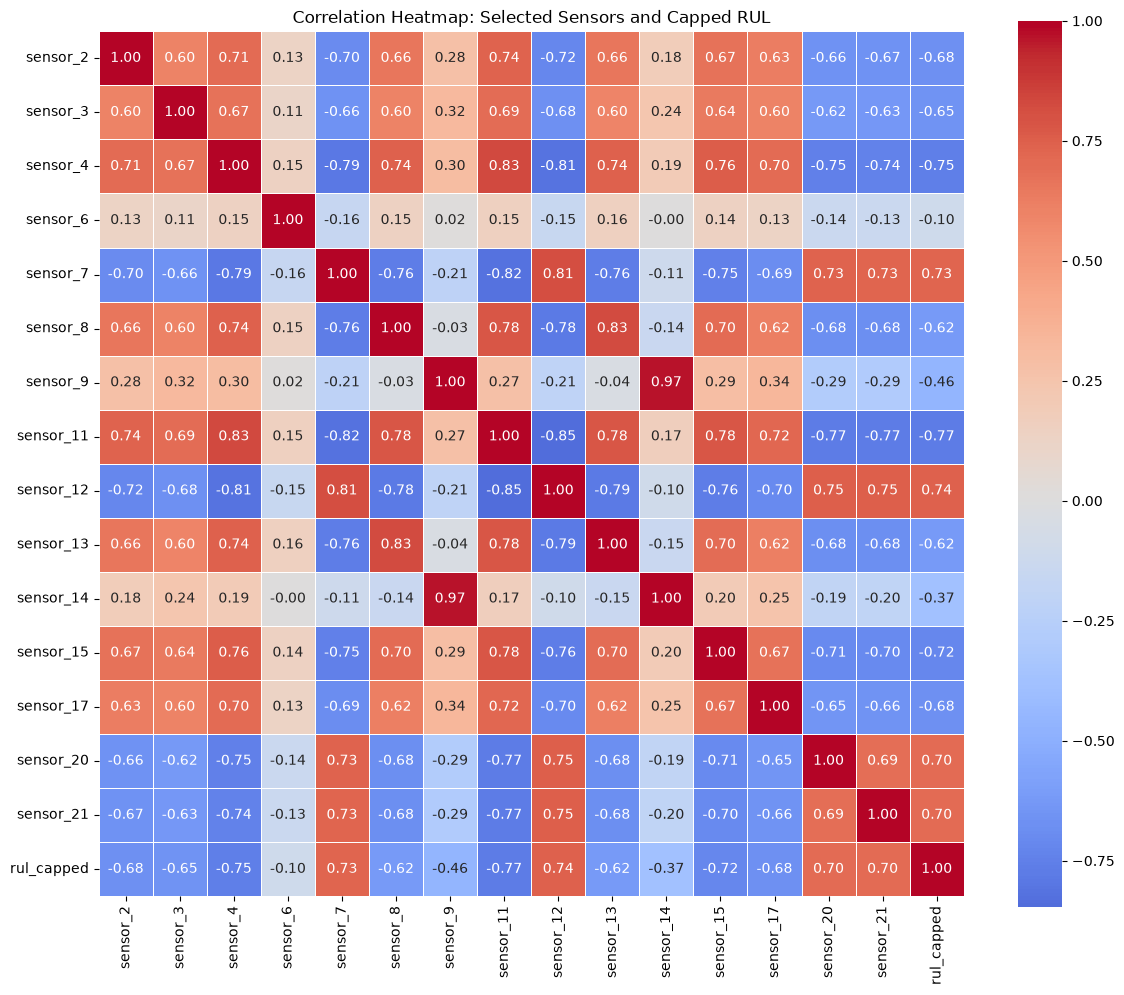

In [9]:
# Use the development-training partition so this view is consistent
# with the sensor-selection logic used later in modeling.
corr_matrix = feature_selection_train[
    selected_sensors + ["rul_capped"]
].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
)
plt.title("Correlation Heatmap: Selected Sensors and Capped RUL")
plt.tight_layout()
save_current_figure("eda_sensor_rul_heatmap.png")
plt.show()


### Interpretation

The heatmap shows which sensor readings tend to move with remaining engine life. Some sensors have a clear positive or negative relationship with capped RUL, while several sensors also move closely with one another. This tells us two things: there is useful degradation signal in the sensor data, and some sensors carry overlapping information. The correlations shown here are based only on the development-training engines so the validation engines do not influence feature selection.


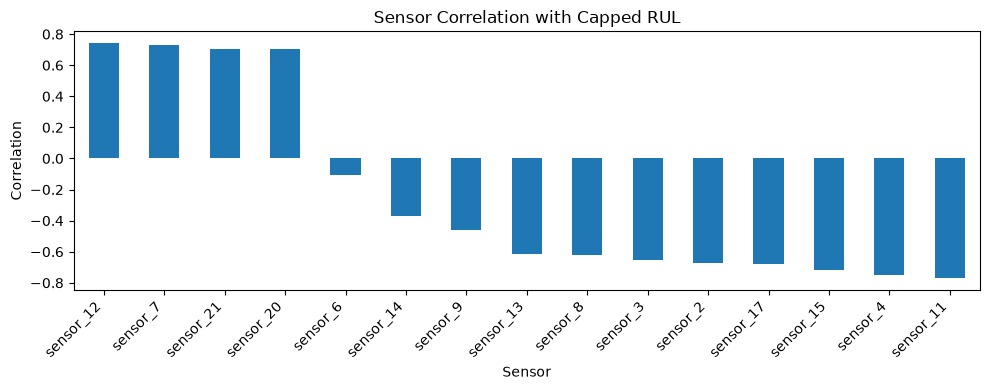

Top 5 sensors by absolute correlation with capped RUL:
['sensor_11', 'sensor_4', 'sensor_12', 'sensor_7', 'sensor_15']


In [10]:
# Order sensors by their correlation with capped RUL.
corr_with_rul = correlation_table["corr_with_rul"]
corr_plot = corr_with_rul.sort_values(ascending=False)

plt.figure(figsize=(10, 4))
corr_plot.plot(kind="bar")
plt.title("Sensor Correlation with Capped RUL")
plt.xlabel("Sensor")
plt.ylabel("Correlation")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
save_current_figure("eda_sensor_rul_correlation.png")
plt.show()

# Keep the strongest sensors for focused EDA views.
top_k = 5
top_sensors = (
    corr_with_rul.abs()
    .sort_values(ascending=False)
    .head(top_k)
    .index
    .tolist()
)

print(f"Top {top_k} sensors by absolute correlation with capped RUL:")
print(top_sensors)


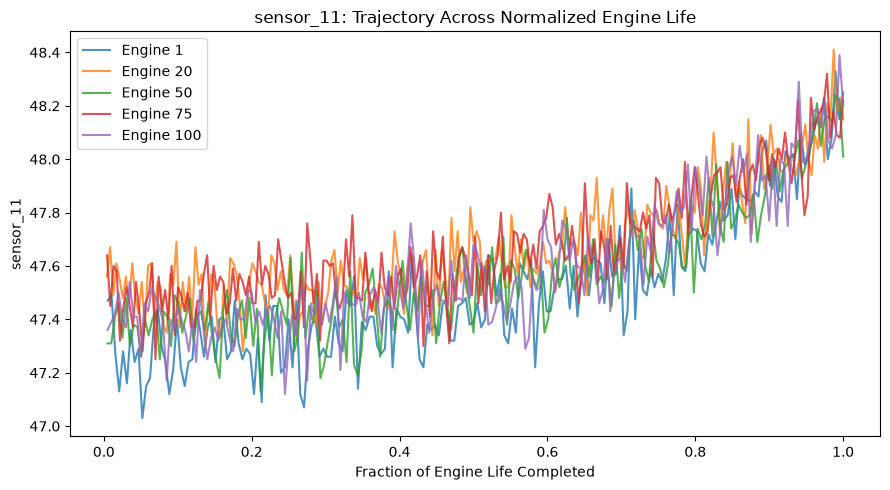

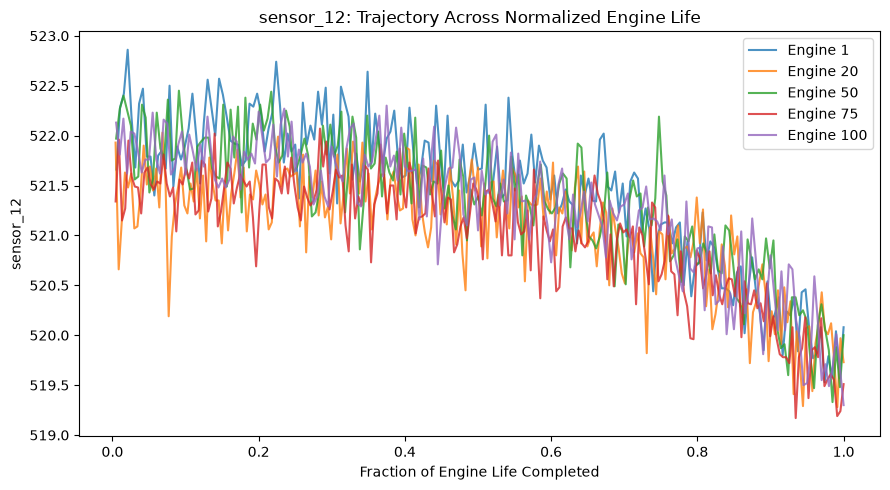

In [11]:
# Compare two strong sensors across a few example engines.
# Normalizing lifetime to 0-1 makes engines with different lifespans comparable.
example_engines = [1, 20, 50, 75, 100]
sensors_to_plot = ["sensor_11", "sensor_12"]

for sensor in sensors_to_plot:
    plt.figure(figsize=(9, 5))

    for engine_id in example_engines:
        engine = train[train["unit_id"] == engine_id]
        life_fraction = engine["cycle"] / engine["max_cycle"]

        plt.plot(
            life_fraction,
            engine[sensor],
            label=f"Engine {engine_id}",
            alpha=0.8,
        )

    plt.title(f"{sensor}: Trajectory Across Normalized Engine Life")
    plt.xlabel("Fraction of Engine Life Completed")
    plt.ylabel(sensor)
    plt.legend()
    plt.tight_layout()
    save_current_figure(f"eda_{sensor}_normalized_trajectory.png")
    plt.show()


### Interpretation

The trajectory plots show that the selected sensors do not stay flat throughout an engine's life. Their readings gradually shift as engines move toward failure, although the exact path differs by engine. This is useful for RUL prediction because the model can use these changes as signals of degradation rather than relying on a single sensor reading in isolation.


#### Sensor behavior across early, middle, and late engine life

To make the degradation pattern easier to read, the next table groups each engine's lifetime into three broad stages and compares the average values of the strongest sensors.


In [12]:
train["life_stage"] = pd.cut(
    train["cycle"] / train["max_cycle"],
    bins=[0.0, 0.33, 0.67, 1.0],
    labels=["Early", "Middle", "Late"],
    include_lowest=True,
)

life_stage_summary = (
    train.groupby("life_stage", observed=False)[top_sensors]
    .mean()
    .T
)

display(life_stage_summary)

life_stage,Early,Middle,Late
sensor_11,47.361125,47.461917,47.799439
sensor_4,1402.993344,1406.310261,1417.464147
sensor_12,521.891528,521.628854,520.722648
sensor_7,553.923362,553.629270,552.553328
sensor_15,8.419186,8.430969,8.476172


### Interpretation

The stage summary makes the direction of degradation easier to see. Sensors whose average values shift from Early to Middle to Late life are especially useful because they provide a consistent signal that the engine's condition is changing over time.


# 4. Leakage-safe feature engineering

Tabular models see one row at a time, so they do not automatically know what happened in the previous few cycles. We therefore add a small set of backward-looking features that summarize recent sensor behavior.


In [13]:
def add_temporal_features(
    df: pd.DataFrame,
    sensors: list[str],
    windows: tuple[int, ...] = (5, 10),
) -> pd.DataFrame:
    """Create backward-looking temporal features separately within each engine."""

    # Sorting is essential: rolling values must follow the true cycle order.
    result = df.sort_values(["unit_id", "cycle"]).copy()
    grouped = result.groupby("unit_id", group_keys=False)

    for sensor in sensors:
        # One-cycle change captures whether the sensor just moved up or down.
        result[f"{sensor}_diff_1"] = (
            grouped[sensor]
            .diff()
            .fillna(0.0)
        )

        for window in windows:
            # Rolling statistics use the current and earlier cycles only.
            rolling = grouped[sensor].rolling(
                window=window,
                min_periods=1,
            )

            result[f"{sensor}_roll_mean_{window}"] = (
                rolling.mean()
                .reset_index(level=0, drop=True)
            )

            result[f"{sensor}_roll_std_{window}"] = (
                rolling.std()
                .reset_index(level=0, drop=True)
                .fillna(0.0)
            )

            # Difference from the recent average highlights unusual movement.
            result[f"{sensor}_minus_mean_{window}"] = (
                result[sensor]
                - result[f"{sensor}_roll_mean_{window}"]
            )

    return result


# Choose the six strongest sensors using development-training engines only.
engineered_sensors = (
    corr_with_rul.abs()
    .sort_values(ascending=False)
    .head(6)
    .index
    .tolist()
)

# Apply exactly the same feature logic to train and test observations.
train_features = add_temporal_features(
    train,
    engineered_sensors,
)
test_features = add_temporal_features(
    test_raw,
    engineered_sensors,
)

print("Engineered sensors:", engineered_sensors)
print("Train feature shape:", train_features.shape)
print("Test feature shape:", test_features.shape)


Engineered sensors: ['sensor_11', 'sensor_4', 'sensor_12', 'sensor_7', 'sensor_15', 'sensor_21']
Train feature shape: (20631, 72)
Test feature shape: (13096, 68)


### Interpretation

The engineered features give the tabular models a small amount of recent history. For the six strongest sensors, we capture the previous-cycle change, recent average, recent variation, and distance from the recent average. Every calculation is performed separately within an engine and uses only the current or earlier cycles, so no future sensor readings are introduced.


In [14]:
# Confirm that target-only columns appear only in the training frame.
train_only_cols = set(train_features.columns) - set(test_features.columns)
test_only_cols = set(test_features.columns) - set(train_features.columns)

print("Train-only columns:", train_only_cols)
print("Test-only columns:", test_only_cols)

metadata = {
    "rul_cap": RUL_CAP,
    "selected_sensors": selected_sensors,
    "engineered_sensors": engineered_sensors,
    "low_variance_cols": low_variance_cols,
    "train_rows": int(len(train_features)),
    "test_rows": int(len(test_features)),
    "train_engines": int(train_features["unit_id"].nunique()),
    "test_engines": int(test_features["unit_id"].nunique()),
}

train_features.to_csv(
    PROCESSED_DIR / "fd001_train_processed.csv",
    index=False,
)
test_features.to_csv(
    PROCESSED_DIR / "fd001_test_processed.csv",
    index=False,
)
test_last_truth.to_csv(
    PROCESSED_DIR / "fd001_test_last_with_rul.csv",
    index=False,
)
correlation_table.to_csv(
    PROCESSED_DIR / "fd001_sensor_correlations.csv",
    index_label="sensor",
)

with open(PROCESSED_DIR / "fd001_metadata.json", "w") as file:
    json.dump(metadata, file, indent=2)

print("Saved processed data to:", PROCESSED_DIR)


Train-only columns: {'rul', 'rul_capped', 'max_cycle', 'life_stage'}
Test-only columns: set()
Saved processed data to: /Users/sudhakaransrinivasan/Documents/GitHub/intelligent-predictive-maintenance/data/processed


The processed files are saved under `data/processed/` so they can be inspected without rerunning every preparation step:

- `fd001_train_processed.csv` — training observations with engineered features
- `fd001_test_processed.csv` — test observations with the same feature logic
- `fd001_test_last_with_rul.csv` — official final RUL target for each test engine
- `fd001_sensor_correlations.csv` — training-only sensor correlations used for feature selection
- `fd001_metadata.json` — preprocessing choices and dataset summary


# 5. Shared evaluation functions and model matrices


In [15]:
def rmse(y_true, y_pred) -> float:
    return float(mean_squared_error(y_true, y_pred) ** 0.5)


def cmapss_score(y_true, y_pred) -> float:
    """NASA asymmetric score; overestimated RUL is penalized more heavily."""
    error = np.asarray(y_pred) - np.asarray(y_true)
    penalties = np.where(
        error < 0,
        np.exp(-error / 13.0) - 1.0,
        np.exp(error / 10.0) - 1.0,
    )
    return float(penalties.sum())


def evaluate_regression(y_true, y_pred, model_name: str) -> dict:
    return {
        "model": model_name,
        "rmse": rmse(y_true, y_pred),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "cmapss_score": cmapss_score(y_true, y_pred),
    }

In [16]:
# Columns that should never be used as model inputs.
excluded = {
    "unit_id",
    "max_cycle",
    "rul",
    "rul_capped",
    "life_stage",
    *low_variance_cols,
}

# Cycle is intentionally retained because engine age is known at prediction time.
feature_cols = [
    column
    for column in train_features.columns
    if column not in excluded
]
target_col = "rul_capped"

# Reuse the engine IDs created before target-based feature selection.
train_part = train_features[
    train_features["unit_id"].isin(train_engine_ids)
].copy()
val_part = train_features[
    train_features["unit_id"].isin(val_engine_ids)
].copy()

X_train = train_part[feature_cols]
y_train = train_part[target_col]
X_val = val_part[feature_cols]
y_val = val_part[target_col]

assert set(train_part["unit_id"]).isdisjoint(set(val_part["unit_id"]))

print("Training engines:", train_part["unit_id"].nunique())
print("Validation engines:", val_part["unit_id"].nunique())
print("Tabular features:", len(feature_cols))


Training engines: 80
Validation engines: 20
Tabular features: 60


### Why the split is by engine

Each engine contributes many cycle-level rows. If rows from the same engine appeared in both training and validation data, the model would see part of that engine during training and the validation score would look better than it really is. Keeping entire engines together gives a more realistic holdout test during model development.


# 6. Baseline and tree-based models

In [17]:
# 6. Baseline models



# Store results and validation predictions.
model_results = []
validation_predictions = {}


# 6.1 Mean baseline
# Predict the average training RUL for every validation row.
mean_val_pred = np.repeat(
    y_train.mean(),
    len(y_val),
)

model_results.append(
    evaluate_regression(
        y_val,
        mean_val_pred,
        "Mean Baseline",
    )
)

validation_predictions["Mean Baseline"] = mean_val_pred


# 6.2 Linear Regression
# Scaling is useful because Linear Regression is sensitive to feature scale.
linear_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LinearRegression()),
])

linear_pipeline.fit(X_train, y_train)

linear_val_pred = np.clip(
    linear_pipeline.predict(X_val),
    0,
    RUL_CAP,
)

model_results.append(
    evaluate_regression(
        y_val,
        linear_val_pred,
        "Linear Regression",
    )
)

validation_predictions["Linear Regression"] = linear_val_pred


# 6.3 Random Forest
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

rf_model.fit(X_train, y_train)

rf_val_pred = np.clip(
    rf_model.predict(X_val),
    0,
    RUL_CAP,
)

model_results.append(
    evaluate_regression(
        y_val,
        rf_val_pred,
        "Random Forest",
    )
)

validation_predictions["Random Forest"] = rf_val_pred


# 6.4 Gradient Boosting
gb_model = GradientBoostingRegressor(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    random_state=RANDOM_STATE,
)

gb_model.fit(X_train, y_train)

gb_val_pred = np.clip(
    gb_model.predict(X_val),
    0,
    RUL_CAP,
)

model_results.append(
    evaluate_regression(
        y_val,
        gb_val_pred,
        "Gradient Boosting",
    )
)

validation_predictions["Gradient Boosting"] = gb_val_pred


# 6.5 Baseline comparison
baseline_comparison = (
    pd.DataFrame(model_results)
    .sort_values(["rmse", "mae"])
    .reset_index(drop=True)
)

display(
    baseline_comparison.style.format({
        "rmse": "{:.2f}",
        "mae": "{:.2f}",
        "cmapss_score": "{:,.0f}",
    })
)

,model,rmse,mae,cmapss_score
0,Gradient Boosting,14.80,10.23,"16,626"
1,Random Forest,15.37,10.12,"19,728"
2,Linear Regression,17.06,12.88,"19,908"
3,Mean Baseline,41.72,36.93,"1,285,856"


### Interpretation

The mean baseline gives us a minimum reference point: a useful model should clearly beat a prediction that simply uses the average training RUL. Linear Regression tests whether the relationship is mostly linear, while Random Forest and Gradient Boosting can learn more complex patterns. Lower RMSE, MAE, and C-MAPSS score indicate better performance.


### Baseline feature importance

In [18]:
# Compare feature importance from Random Forest and Gradient Boosting.

baseline_importance = pd.DataFrame({
    "feature": feature_cols,
    "random_forest": rf_model.feature_importances_,
    "gradient_boosting": gb_model.feature_importances_,
})

rf_top_features = (
    baseline_importance
    .sort_values("random_forest", ascending=False)
    .head(15)
)

gb_top_features = (
    baseline_importance
    .sort_values("gradient_boosting", ascending=False)
    .head(15)
)

display(rf_top_features)
display(gb_top_features)

,feature,random_forest,gradient_boosting
29,sensor_4_roll_mean_10,0.388617,0.135954
26,sensor_4_roll_mean_5,0.225531,0.196308
0,cycle,0.145910,0.138898
22,sensor_11_roll_mean_10,0.048516,0.045355
50,sensor_15_roll_mean_10,0.036672,0.144980
9,sensor_9,0.035001,0.031525
57,sensor_21_roll_mean_10,0.021564,0.040174
19,sensor_11_roll_mean_5,0.014665,0.121921
47,sensor_15_roll_mean_5,0.013637,0.062983
13,sensor_14,0.013048,0.018151


,feature,random_forest,gradient_boosting
26,sensor_4_roll_mean_5,0.225531,0.196308
50,sensor_15_roll_mean_10,0.036672,0.144980
0,cycle,0.145910,0.138898
29,sensor_4_roll_mean_10,0.388617,0.135954
19,sensor_11_roll_mean_5,0.014665,0.121921
47,sensor_15_roll_mean_5,0.013637,0.062983
22,sensor_11_roll_mean_10,0.048516,0.045355
57,sensor_21_roll_mean_10,0.021564,0.040174
9,sensor_9,0.035001,0.031525
54,sensor_21_roll_mean_5,0.002466,0.029541


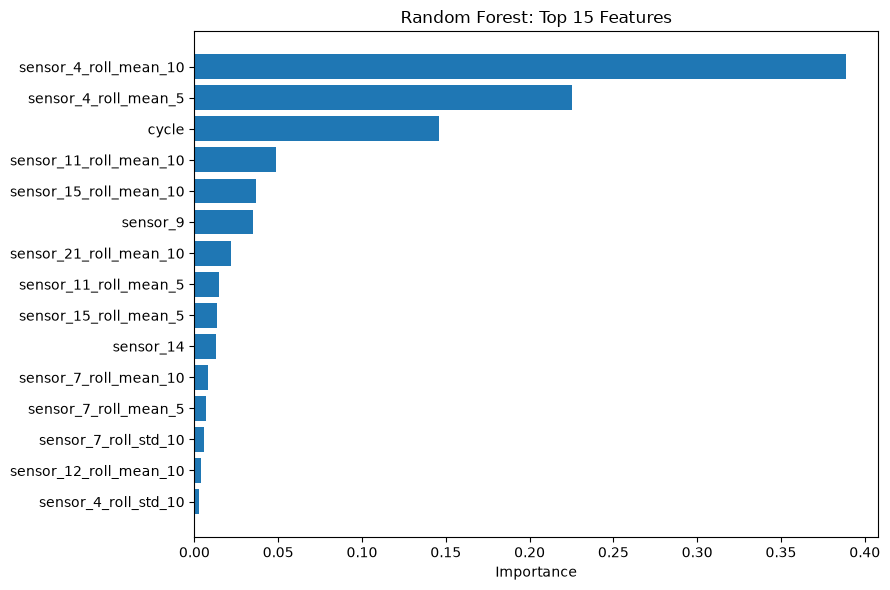

In [19]:
# Random Forest feature importance
plt.figure(figsize=(9, 6))
plt.barh(
    rf_top_features["feature"][::-1],
    rf_top_features["random_forest"][::-1],
)
plt.xlabel("Importance")
plt.title("Random Forest: Top 15 Features")
plt.tight_layout()
save_current_figure("random_forest_feature_importance.png")
plt.show()


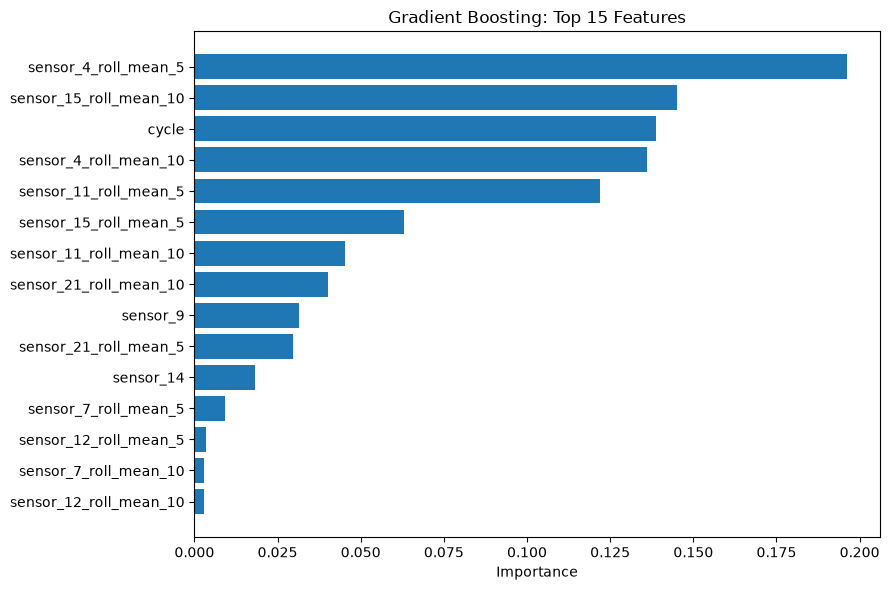

In [20]:
# Gradient Boosting feature importance
plt.figure(figsize=(9, 6))
plt.barh(
    gb_top_features["feature"][::-1],
    gb_top_features["gradient_boosting"][::-1],
)
plt.xlabel("Importance")
plt.title("Gradient Boosting: Top 15 Features")
plt.tight_layout()
save_current_figure("gradient_boosting_feature_importance.png")
plt.show()


In [21]:
# Break validation errors into RUL ranges to see where the model struggles most.
def rul_band(values: pd.Series) -> pd.Categorical:
    return pd.cut(
        values,
        bins=[-1, 25, 50, 100, RUL_CAP],
        labels=["0-25", "26-50", "51-100", "101-125"],
    )


rf_error_analysis = pd.DataFrame({
    "actual_rul": y_val.to_numpy(),
    "predicted_rul": rf_val_pred,
})
rf_error_analysis["error"] = (
    rf_error_analysis["predicted_rul"]
    - rf_error_analysis["actual_rul"]
)
rf_error_analysis["rul_band"] = rul_band(
    rf_error_analysis["actual_rul"]
)

rf_error_by_band = (
    rf_error_analysis
    .groupby("rul_band", observed=False)
    .agg(
        observations=("error", "size"),
        mae=("error", lambda values: np.abs(values).mean()),
        mean_signed_error=("error", "mean"),
    )
)

display(rf_error_by_band)


,observations,mae,mean_signed_error
rul_band,,,
0-25,520,4.099792,2.664778
26-50,500,12.084955,8.618423
51-100,1000,17.458010,10.094081
101-125,2050,7.587430,-5.980631


### Baseline model readout

The tree models help show which inputs are carrying the prediction. If engineered rolling features appear near the top, it means recent sensor behavior is adding information beyond the raw reading itself. The RUL-band table is also useful because an overall average can hide where errors are concentrated; maintenance decisions are especially sensitive to performance when an engine is closer to failure.


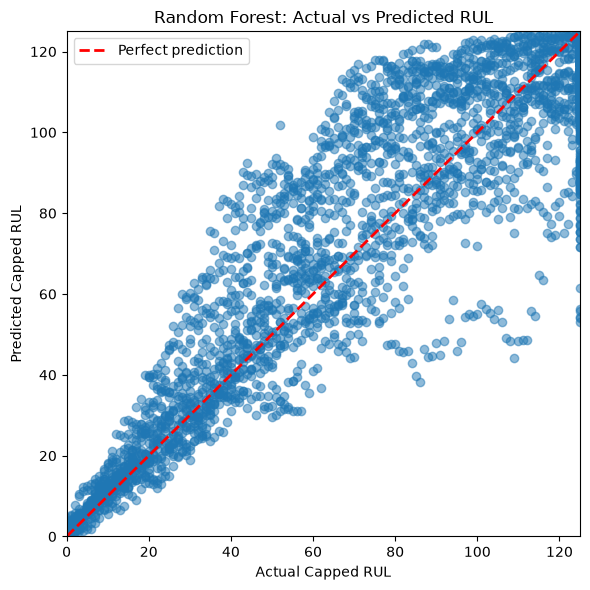

In [22]:
# Actual vs. predicted values provide a direct visual check for Random Forest.
plt.figure(figsize=(6, 6))
plt.scatter(
    y_val,
    rf_val_pred,
    alpha=0.5,
)

plot_min = min(float(y_val.min()), float(rf_val_pred.min()))
plot_max = max(float(y_val.max()), float(rf_val_pred.max()))

plt.plot(
    [plot_min, plot_max],
    [plot_min, plot_max],
    "r--",
    linewidth=2,
    label="Perfect prediction",
)
plt.xlim(plot_min, plot_max)
plt.ylim(plot_min, plot_max)
plt.xlabel("Actual Capped RUL")
plt.ylabel("Predicted Capped RUL")
plt.title("Random Forest: Actual vs Predicted RUL")
plt.legend()
plt.tight_layout()
save_current_figure("random_forest_actual_vs_predicted.png")
plt.show()


# 7. Advanced Machine Learning: XGBoost

In [23]:
initial_xgb = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=200,
    max_depth=3,
    learning_rate=0.10,
    subsample=0.80,
    colsample_bytree=0.80,
    reg_lambda=1.0,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method="hist",
)

initial_xgb.fit(X_train, y_train)

initial_xgb_val_pred = np.clip(
    initial_xgb.predict(X_val),
    0,
    RUL_CAP,
)

model_results.append(
    evaluate_regression(
        y_val,
        initial_xgb_val_pred,
        "Initial XGBoost",
    )
)

validation_predictions["Initial XGBoost"] = initial_xgb_val_pred

display(
    pd.DataFrame([
        evaluate_regression(
            y_val,
            initial_xgb_val_pred,
            "Initial XGBoost",
        )
    ]).style.format({
        "rmse": "{:.2f}",
        "mae": "{:.2f}",
        "cmapss_score": "{:,.0f}",
    })
)

,model,rmse,mae,cmapss_score
0,Initial XGBoost,14.74,10.09,"16,634"


In [24]:
# Engine IDs associated with each row in X_train.
training_groups = train_part["unit_id"]

group_cv = GroupKFold(n_splits=3)

xgb_tuning_model = XGBRegressor(
    objective="reg:squarederror",
    subsample=0.80,
    colsample_bytree=0.80,
    reg_lambda=1.0,
    random_state=RANDOM_STATE,
    n_jobs=1,
    tree_method="hist",
)

parameter_grid = {
    "n_estimators": [200, 400,600],
    "max_depth": [2, 3, 4],
    "learning_rate": [0.03, 0.05, 0.10],
}

grid_search = GridSearchCV(
    estimator=xgb_tuning_model,
    param_grid=parameter_grid,
    scoring="neg_root_mean_squared_error",
    cv=group_cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
)

grid_search.fit(
    X_train,
    y_train,
    groups=training_groups,
)

tuned_xgb = grid_search.best_estimator_

print("Best parameters:", grid_search.best_params_)
print(
    "Best cross-validation RMSE:",
    round(-grid_search.best_score_, 2),
)

Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best parameters: {'learning_rate': 0.03, 'max_depth': 4, 'n_estimators': 600}
Best cross-validation RMSE: 16.35


The XGBoost hyperparameters are selected using grouped cross-validation on the development-training engines only. Grouping by engine prevents cycles from the same engine from appearing in both a training and validation fold. The tuned model is then evaluated once on the 20 held-out validation engines.


In [25]:
tuned_xgb_val_pred = np.clip(
    tuned_xgb.predict(X_val),
    0,
    RUL_CAP,
)

model_results.append(
    evaluate_regression(
        y_val,
        tuned_xgb_val_pred,
        "Tuned XGBoost",
    )
)

validation_predictions["Tuned XGBoost"] = tuned_xgb_val_pred

tuned_xgb_metrics = evaluate_regression(
    y_val,
    tuned_xgb_val_pred,
    "Tuned XGBoost",
)

display(
    pd.DataFrame([tuned_xgb_metrics]).style.format({
        "rmse": "{:.2f}",
        "mae": "{:.2f}",
        "cmapss_score": "{:,.0f}",
    })
)

,model,rmse,mae,cmapss_score
0,Tuned XGBoost,14.69,9.93,"17,074"


### Interpretation

The tuned XGBoost result shows whether grouped cross-validation produced a meaningful improvement over the initial XGBoost settings. The important comparison is against the same held-out validation engines used by the other tabular models, not the cross-validation score by itself.


In [26]:
xgb_error_analysis = pd.DataFrame({
    "actual_rul": y_val.to_numpy(),
    "predicted_rul": tuned_xgb_val_pred,
})

xgb_error_analysis["error"] = (
    xgb_error_analysis["predicted_rul"]
    - xgb_error_analysis["actual_rul"]
)

xgb_error_analysis["absolute_error"] = (
    xgb_error_analysis["error"].abs()
)

xgb_error_analysis["rul_band"] = rul_band(
    xgb_error_analysis["actual_rul"]
)

xgb_error_by_band = (
    xgb_error_analysis
    .groupby("rul_band", observed=False)
    .agg(
        observations=("error", "size"),
        mae=("absolute_error", "mean"),
        mean_signed_error=("error", "mean"),
    )
    .reset_index()
)

display(
    xgb_error_by_band.style.format({
        "mae": "{:.2f}",
        "mean_signed_error": "{:.2f}",
    })
)

,rul_band,observations,mae,mean_signed_error
0,0-25,520,4.40,2.84
1,26-50,500,11.47,8.17
2,51-100,1000,16.70,9.58
3,101-125,2050,7.65,-6.16


### Error by RUL range

This table shows where XGBoost makes its largest errors. The `mean_signed_error` is also useful: a positive value means the model tends to predict too much remaining life in that range, while a negative value means it tends to predict too little.


In [27]:
xgb_builtin_importance = (
    pd.DataFrame({
        "feature": feature_cols,
        "xgboost_importance": tuned_xgb.feature_importances_,
    })
    .sort_values("xgboost_importance", ascending=False)
    .head(15)
)

display(xgb_builtin_importance)

,feature,xgboost_importance
26,sensor_4_roll_mean_5,0.195252
29,sensor_4_roll_mean_10,0.165467
19,sensor_11_roll_mean_5,0.144084
50,sensor_15_roll_mean_10,0.129407
22,sensor_11_roll_mean_10,0.081008
47,sensor_15_roll_mean_5,0.069968
0,cycle,0.026041
9,sensor_9,0.024033
54,sensor_21_roll_mean_5,0.021283
57,sensor_21_roll_mean_10,0.018104


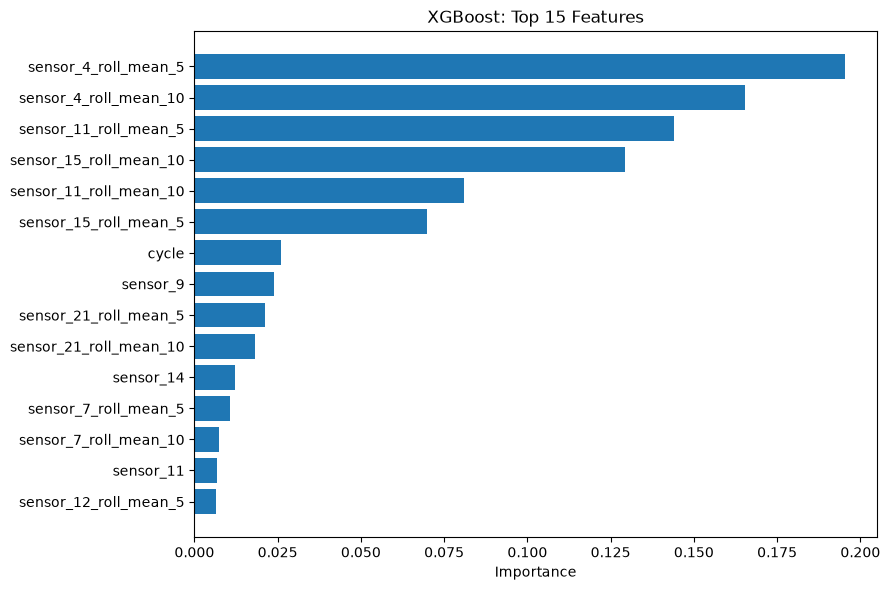

In [28]:
plt.figure(figsize=(9, 6))
plt.barh(
    xgb_builtin_importance["feature"][::-1],
    xgb_builtin_importance["xgboost_importance"][::-1],
)
plt.xlabel("Importance")
plt.title("XGBoost: Top 15 Features")
plt.tight_layout()
save_current_figure("xgboost_feature_importance.png")
plt.show()


# 8. Combined tabular model comparison


In [29]:
# 8. Combined comparison of all tabular models

tabular_model_comparison = (
    pd.DataFrame(model_results)
    .drop_duplicates(
        subset="model",
        keep="last",
    )
    .sort_values(
        ["rmse", "mae", "cmapss_score"],
        ascending=True,
    )
    .reset_index(drop=True)
)

display(
    tabular_model_comparison.style.format({
        "rmse": "{:.2f}",
        "mae": "{:.2f}",
        "cmapss_score": "{:,.0f}",
    })
)

,model,rmse,mae,cmapss_score
0,Tuned XGBoost,14.69,9.93,"17,074"
1,Initial XGBoost,14.74,10.09,"16,634"
2,Gradient Boosting,14.80,10.23,"16,626"
3,Random Forest,15.37,10.12,"19,728"
4,Linear Regression,17.06,12.88,"19,908"
5,Mean Baseline,41.72,36.93,"1,285,856"


### Interpretation

This table gives the cleanest comparison across the tabular models because every model is evaluated on the same held-out engines and the same capped RUL target. The first row is the best tabular model under the chosen sorting rule.


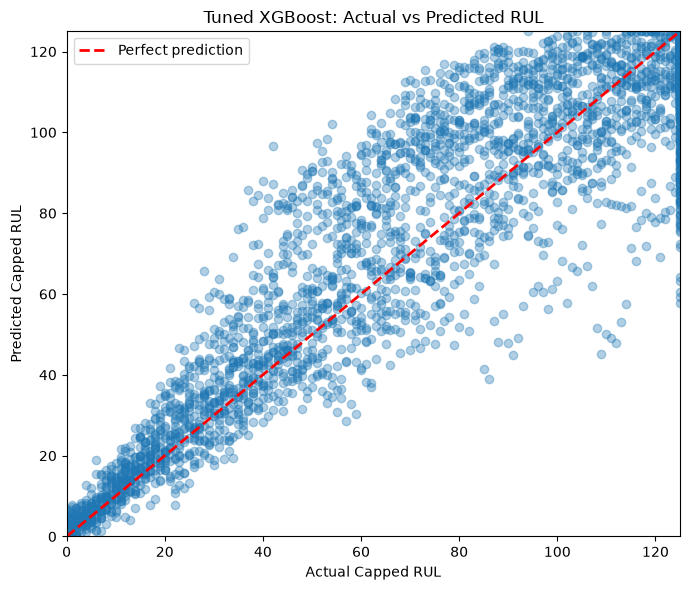

Best tabular model: Tuned XGBoost


In [30]:
best_tabular_model_name = tabular_model_comparison.iloc[0]["model"]
best_tabular_predictions = validation_predictions[best_tabular_model_name]

plt.figure(figsize=(7, 6))
plt.scatter(
    y_val,
    best_tabular_predictions,
    alpha=0.35,
)

plot_min = min(
    float(y_val.min()),
    float(best_tabular_predictions.min()),
)
plot_max = max(
    float(y_val.max()),
    float(best_tabular_predictions.max()),
)

plt.plot(
    [plot_min, plot_max],
    [plot_min, plot_max],
    "r--",
    linewidth=2,
    label="Perfect prediction",
)
plt.xlim(plot_min, plot_max)
plt.ylim(plot_min, plot_max)
plt.xlabel("Actual Capped RUL")
plt.ylabel("Predicted Capped RUL")
plt.title(f"{best_tabular_model_name}: Actual vs Predicted RUL")
plt.legend()
plt.tight_layout()
save_current_figure("best_tabular_actual_vs_predicted.png")
plt.show()

print("Best tabular model:", best_tabular_model_name)


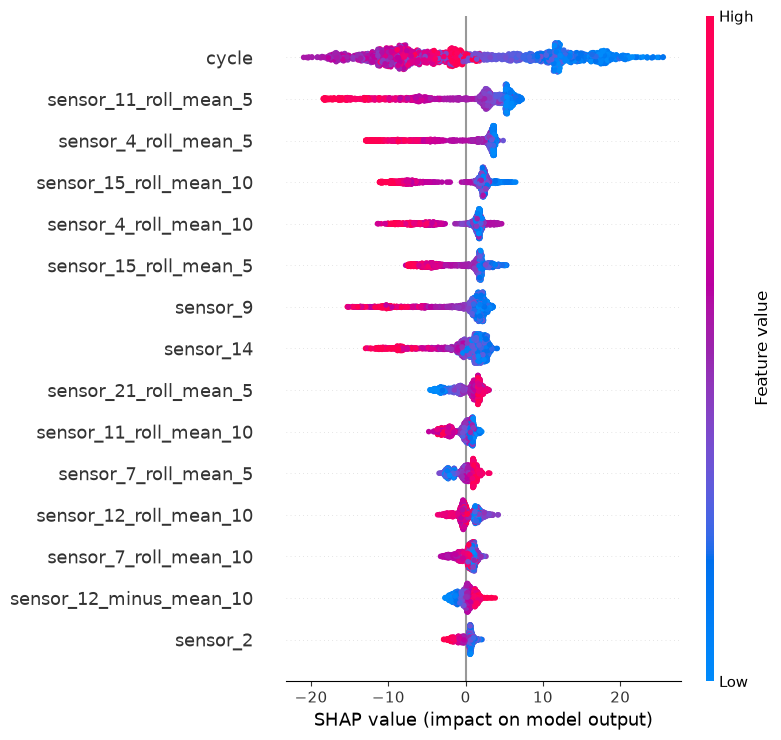

In [31]:
import shap

# Explain a manageable sample of the held-out validation rows.
X_shap = X_val.sample(
    n=min(2000, len(X_val)),
    random_state=RANDOM_STATE,
)

explainer = shap.TreeExplainer(tuned_xgb)
shap_values = explainer.shap_values(X_shap)

# Each point shows whether a feature pushed the predicted RUL up or down.
shap.summary_plot(
    shap_values,
    X_shap,
    max_display=15,
    show=False,
)
plt.tight_layout()
save_current_figure("xgboost_shap_summary.png")
plt.show()


### Interpretation

The SHAP plot explains the XGBoost predictions in plain terms. Features near the top have the largest overall effect. Lower cycle values generally push the predicted RUL upward, while higher cycle values push it downward, which is consistent with engine age. Several rolling sensor features also appear near the top, showing that recent sensor behavior adds useful information beyond the current reading.


# 9. Recurrent neural networks: shared sequence pipeline

Unlike the tabular models, LSTM and GRU receive an ordered 30-cycle history for each prediction. Because the sequence already contains recent history, we use the raw sensor trajectories rather than adding rolling features again.


In [32]:
try:
    import torch
    from torch import nn
    from torch.utils.data import DataLoader, Dataset
except ImportError as error:
    raise ImportError(
        "Install PyTorch in the active environment before running this section."
    ) from error

torch.manual_seed(RANDOM_STATE)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print("Device:", DEVICE)

Device: mps


In [33]:
# RNNs use raw operating context and sensor trajectories, not engineered rolling features.
sequence_features = [
    column
    for column in setting_cols + selected_sensors
    if column not in low_variance_cols
]

sequence_train = train[
    ["unit_id", "cycle", "rul_capped"] + sequence_features
].copy()
sequence_test = test_raw[
    ["unit_id", "cycle"] + sequence_features
].copy()

# Reuse exactly the same engine split used by the tabular models.
sequence_train_part = sequence_train[
    sequence_train["unit_id"].isin(train_engine_ids)
].copy()
sequence_val_part = sequence_train[
    sequence_train["unit_id"].isin(val_engine_ids)
].copy()

# Fit the scaler on development-training engines only.
sequence_scaler = StandardScaler()
sequence_scaler.fit(sequence_train_part[sequence_features])

sequence_train_part.loc[:, sequence_features] = (
    sequence_scaler.transform(sequence_train_part[sequence_features])
)
sequence_val_part.loc[:, sequence_features] = (
    sequence_scaler.transform(sequence_val_part[sequence_features])
)

print("Sequence features:", sequence_features)


Sequence features: ['setting_1', 'setting_2', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


In [34]:
def build_train_sequences(
    df: pd.DataFrame,
    features: list[str],
    target: str,
    sequence_length: int,
):
    X, y, unit_ids = [], [], []

    for unit_id, engine in df.groupby("unit_id"):
        engine = engine.sort_values("cycle")
        values = engine[features].to_numpy(dtype=np.float32)
        targets = engine[target].to_numpy(dtype=np.float32)

        if len(engine) < sequence_length:
            continue

        for end in range(sequence_length, len(engine) + 1):
            start = end - sequence_length
            X.append(values[start:end])
            y.append(targets[end - 1])
            unit_ids.append(unit_id)

    return (
        np.asarray(X, dtype=np.float32),
        np.asarray(y, dtype=np.float32),
        np.asarray(unit_ids),
    )


X_train_seq, y_train_seq, train_seq_units = build_train_sequences(
    sequence_train_part,
    sequence_features,
    "rul_capped",
    SEQUENCE_LENGTH,
)
X_val_seq, y_val_seq, val_seq_units = build_train_sequences(
    sequence_val_part,
    sequence_features,
    "rul_capped",
    SEQUENCE_LENGTH,
)

print("Train sequences:", X_train_seq.shape)
print("Validation sequences:", X_val_seq.shape)

Train sequences: (14241, 30, 17)
Validation sequences: (3490, 30, 17)


In [35]:
class SequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(
            X.astype(np.float32, copy=False)
        )
        self.y = torch.from_numpy(
            y.astype(np.float32, copy=False)
        ).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
        return self.X[index], self.y[index]


train_loader = DataLoader(
    SequenceDataset(X_train_seq, y_train_seq),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
)
val_loader = DataLoader(
    SequenceDataset(X_val_seq, y_val_seq),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

### Sequence preparation

Each deep-learning example contains the previous 30 cycles for one engine and predicts RUL at the final cycle in that window. This gives LSTM and GRU direct access to the recent trajectory rather than a single row of sensor values.


# 10. LSTM/GRU architecture comparison


In [36]:
class RULRecurrentModel(nn.Module):
    """One configurable implementation for both LSTM and GRU experiments."""

    def __init__(
        self,
        input_size,
        rnn_type="GRU",
        hidden_size=64,
        num_layers=1,
        dropout=0.20,
    ):
        super().__init__()

        rnn_type = rnn_type.upper()
        recurrent_class = {
            "LSTM": nn.LSTM,
            "GRU": nn.GRU,
        }.get(rnn_type)

        if recurrent_class is None:
            raise ValueError("rnn_type must be 'LSTM' or 'GRU'.")

        self.rnn_type = rnn_type
        self.recurrent = recurrent_class(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        self.regressor = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        output, _ = self.recurrent(x)
        return self.regressor(output[:, -1, :])

In [37]:
def run_epoch(model, loader, criterion, optimizer=None):
    is_training = optimizer is not None
    model.train(is_training)

    total_loss = 0.0
    total_examples = 0

    with torch.set_grad_enabled(is_training):
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            if is_training:
                optimizer.zero_grad()

            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)

            if is_training:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm=1.0,
                )
                optimizer.step()

            batch_size = X_batch.size(0)
            total_loss += loss.item() * batch_size
            total_examples += batch_size

    return total_loss / total_examples


def predict_loader(model, loader):
    model.eval()
    predictions, actuals = [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            predictions.append(
                model(X_batch.to(DEVICE)).cpu().numpy()
            )
            actuals.append(y_batch.numpy())

    return (
        np.concatenate(actuals).ravel(),
        np.concatenate(predictions).ravel(),
    )

In [38]:
def run_recurrent_experiment(config: dict) -> dict:
    """Train one architecture with early stopping and return all artifacts."""
    random.seed(RANDOM_STATE)
    np.random.seed(RANDOM_STATE)
    torch.manual_seed(RANDOM_STATE)

    model = RULRecurrentModel(
        input_size=len(sequence_features),
        rnn_type=config["rnn_type"],
        hidden_size=config["hidden_size"],
        num_layers=config["num_layers"],
        dropout=config["dropout"],
    ).to(DEVICE)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=config.get("learning_rate", 1e-3),
        weight_decay=config.get("weight_decay", 1e-5),
    )

    history = {"train_loss": [], "val_loss": []}
    best_state = None
    best_val_loss = np.inf
    best_epoch = None
    epochs_without_improvement = 0

    for epoch in range(1, MAX_EPOCHS + 1):
        train_loss = run_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
        )
        val_loss = run_epoch(
            model,
            val_loader,
            criterion,
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        print(
            f"{config['name']} | Epoch {epoch:02d} | "
            f"Train RMSE {train_loss ** 0.5:.3f} | "
            f"Val RMSE {val_loss ** 0.5:.3f}"
        )

        if epochs_without_improvement >= PATIENCE:
            print(f"{config['name']}: early stopping.")
            break

    if best_state is None:
        raise RuntimeError("No model state was saved.")

    model.load_state_dict(best_state)
    y_actual, y_pred = predict_loader(model, val_loader)
    y_pred = np.clip(y_pred, 0, RUL_CAP)

    result = evaluate_regression(
        y_actual,
        y_pred,
        config["name"],
    )
    result.update({
        "rnn_type": config["rnn_type"],
        "hidden_size": config["hidden_size"],
        "num_layers": config["num_layers"],
        "dropout": config["dropout"],
        "best_epoch": best_epoch,
    })

    return {
        "model": model,
        "history": history,
        "result": result,
        "config": config,
    }


In [39]:
# Same architecture search space for LSTM and GRU.
recurrent_configs = [
    {
        "name": "LSTM_64x1",
        "rnn_type": "LSTM",
        "hidden_size": 64,
        "num_layers": 1,
        "dropout": 0.20,
    },
    {
        "name": "LSTM_96x2",
        "rnn_type": "LSTM",
        "hidden_size": 96,
        "num_layers": 2,
        "dropout": 0.25,
    },
    {
        "name": "LSTM_128x2",
        "rnn_type": "LSTM",
        "hidden_size": 128,
        "num_layers": 2,
        "dropout": 0.30,
    },
    {
        "name": "GRU_64x1",
        "rnn_type": "GRU",
        "hidden_size": 64,
        "num_layers": 1,
        "dropout": 0.20,
    },
    {
        "name": "GRU_96x2",
        "rnn_type": "GRU",
        "hidden_size": 96,
        "num_layers": 2,
        "dropout": 0.25,
    },
    {
        "name": "GRU_128x2",
        "rnn_type": "GRU",
        "hidden_size": 128,
        "num_layers": 2,
        "dropout": 0.30,
    },
]

recurrent_experiments = {}

for config in recurrent_configs:
    print("\n" + "=" * 72)
    print("Training:", config["name"])
    print("=" * 72)
    recurrent_experiments[config["name"]] = (
        run_recurrent_experiment(config)
    )


Training: LSTM_64x1
LSTM_64x1 | Epoch 01 | Train RMSE 89.141 | Val RMSE 83.958
LSTM_64x1 | Epoch 02 | Train RMSE 79.237 | Val RMSE 72.049
LSTM_64x1 | Epoch 03 | Train RMSE 65.833 | Val RMSE 56.983
LSTM_64x1 | Epoch 04 | Train RMSE 49.612 | Val RMSE 39.075
LSTM_64x1 | Epoch 05 | Train RMSE 32.062 | Val RMSE 23.045
LSTM_64x1 | Epoch 06 | Train RMSE 20.909 | Val RMSE 16.104
LSTM_64x1 | Epoch 07 | Train RMSE 17.500 | Val RMSE 14.325
LSTM_64x1 | Epoch 08 | Train RMSE 15.547 | Val RMSE 12.555
LSTM_64x1 | Epoch 09 | Train RMSE 14.274 | Val RMSE 12.936
LSTM_64x1 | Epoch 10 | Train RMSE 13.694 | Val RMSE 12.289
LSTM_64x1 | Epoch 11 | Train RMSE 13.535 | Val RMSE 12.428
LSTM_64x1 | Epoch 12 | Train RMSE 13.166 | Val RMSE 12.518
LSTM_64x1 | Epoch 13 | Train RMSE 12.730 | Val RMSE 12.185
LSTM_64x1 | Epoch 14 | Train RMSE 12.583 | Val RMSE 14.124
LSTM_64x1 | Epoch 15 | Train RMSE 12.737 | Val RMSE 12.802
LSTM_64x1 | Epoch 16 | Train RMSE 12.301 | Val RMSE 12.361
LSTM_64x1 | Epoch 17 | Train RMSE 1

In [40]:
recurrent_comparison = (
    pd.DataFrame([
        experiment["result"]
        for experiment in recurrent_experiments.values()
    ])
    .sort_values(["cmapss_score", "rmse", "mae"])
    .reset_index(drop=True)
)

display(
    recurrent_comparison.style.format({
        "rmse": "{:.2f}",
        "mae": "{:.2f}",
        "cmapss_score": "{:,.0f}",
        "dropout": "{:.2f}",
    })
)

best_lstm_row = (
    recurrent_comparison[
        recurrent_comparison["rnn_type"] == "LSTM"
    ]
    .sort_values(["cmapss_score", "rmse"])
    .iloc[0]
)
best_gru_row = (
    recurrent_comparison[
        recurrent_comparison["rnn_type"] == "GRU"
    ]
    .sort_values(["cmapss_score", "rmse"])
    .iloc[0]
)

best_lstm_config = recurrent_experiments[
    best_lstm_row["model"]
]["config"]
best_gru_config = recurrent_experiments[
    best_gru_row["model"]
]["config"]

best_lstm_epoch = int(best_lstm_row["best_epoch"])
best_gru_epoch = int(best_gru_row["best_epoch"])

print("Selected LSTM:", best_lstm_config, "Epochs:", best_lstm_epoch)
print("Selected GRU:", best_gru_config, "Epochs:", best_gru_epoch)

# Select the recurrent model family using validation results only.
selected_recurrent_model_name = recurrent_comparison.iloc[0]["model"]

print("Validation-selected recurrent model:", selected_recurrent_model_name)


,model,rmse,mae,cmapss_score,rnn_type,hidden_size,num_layers,dropout,best_epoch
0,GRU_128x2,12.36,8.91,"8,544",GRU,128,2,0.30,7
1,GRU_64x1,12.29,8.86,"9,106",GRU,64,1,0.20,23
2,LSTM_64x1,12.18,8.46,"9,933",LSTM,64,1,0.20,13
3,GRU_96x2,12.22,8.88,"9,966",GRU,96,2,0.25,7
4,LSTM_128x2,12.32,8.80,"10,335",LSTM,128,2,0.30,8
5,LSTM_96x2,12.47,8.68,"10,799",LSTM,96,2,0.25,10


Selected LSTM: {'name': 'LSTM_64x1', 'rnn_type': 'LSTM', 'hidden_size': 64, 'num_layers': 1, 'dropout': 0.2} Epochs: 13
Selected GRU: {'name': 'GRU_128x2', 'rnn_type': 'GRU', 'hidden_size': 128, 'num_layers': 2, 'dropout': 0.3} Epochs: 7
Validation-selected recurrent model: GRU_128x2


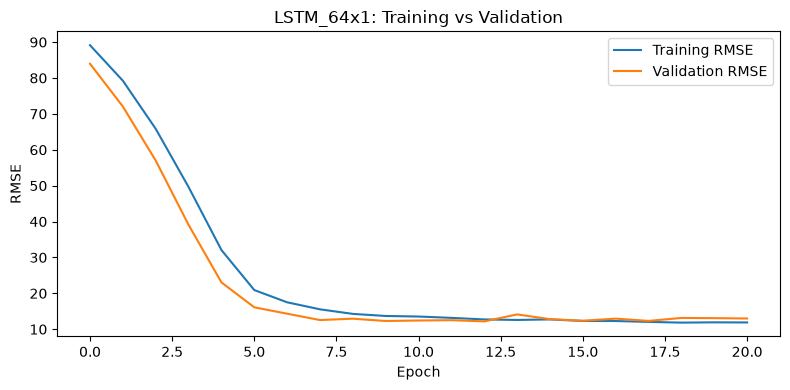

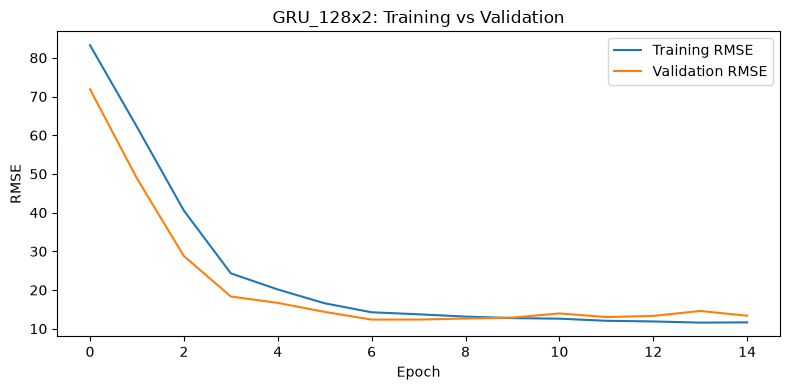

In [41]:
# Plot training and validation RMSE for the best LSTM and GRU configurations.
for model_name in [best_lstm_row["model"], best_gru_row["model"]]:
    history = recurrent_experiments[model_name]["history"]

    plt.figure(figsize=(8, 4))
    plt.plot(
        np.sqrt(history["train_loss"]),
        label="Training RMSE",
    )
    plt.plot(
        np.sqrt(history["val_loss"]),
        label="Validation RMSE",
    )
    plt.xlabel("Epoch")
    plt.ylabel("RMSE")
    plt.title(f"{model_name}: Training vs Validation")
    plt.legend()
    plt.tight_layout()
    save_current_figure(f"{model_name.lower()}_learning_curve.png")
    plt.show()


The learning curves show whether the recurrent models are still improving or starting to overfit. A growing gap between training and validation error would suggest that the model is learning the training sequences more closely than it generalizes to unseen engines.


### Interpretation

The LSTM and GRU configurations are compared on the same held-out engines. A larger or deeper network is kept only if it improves validation performance; more complexity is not automatically better. The model shown at the top of the table is the recurrent model selected for the downstream maintenance agent, before the official test results are examined.


# 11. Final recurrent-model training and official NASA test evaluation

The architecture choice is made from validation results first. The selected LSTM and GRU configurations are then retrained on all 100 training engines before the official test set is evaluated.


In [42]:
# Fit preprocessing again using every training engine.
full_sequence_scaler = StandardScaler()
full_sequence_scaler.fit(sequence_train[sequence_features])

full_train_scaled = sequence_train.copy()
full_test_scaled = sequence_test.copy()

full_train_scaled.loc[:, sequence_features] = (
    full_sequence_scaler.transform(
        full_train_scaled[sequence_features]
    )
)
full_test_scaled.loc[:, sequence_features] = (
    full_sequence_scaler.transform(
        full_test_scaled[sequence_features]
    )
)

X_all_seq, y_all_seq, all_seq_units = build_train_sequences(
    full_train_scaled,
    sequence_features,
    "rul_capped",
    SEQUENCE_LENGTH,
)

all_train_loader = DataLoader(
    SequenceDataset(X_all_seq, y_all_seq),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
)

print("All-training sequences:", X_all_seq.shape)

All-training sequences: (17731, 30, 17)


In [43]:
def build_last_sequences(
    df: pd.DataFrame,
    features: list[str],
    sequence_length: int,
):
    """Build one final sequence per test engine for official evaluation."""
    X, unit_ids = [], []

    for unit_id, engine in df.groupby("unit_id"):
        engine = engine.sort_values("cycle")
        values = engine[features].to_numpy(dtype=np.float32)

        if len(values) >= sequence_length:
            sequence = values[-sequence_length:]
        else:
            # Pad short histories using the earliest available reading.
            padding = np.repeat(
                values[[0]],
                sequence_length - len(values),
                axis=0,
            )
            sequence = np.vstack([padding, values])

        X.append(sequence)
        unit_ids.append(unit_id)

    return (
        np.asarray(X, dtype=np.float32),
        np.asarray(unit_ids),
    )


X_test_last_seq, test_unit_ids = build_last_sequences(
    full_test_scaled,
    sequence_features,
    SEQUENCE_LENGTH,
)

test_truth_aligned = (
    test_last_truth
    .sort_values("unit_id")
    .reset_index(drop=True)
)

assert np.array_equal(
    test_unit_ids,
    test_truth_aligned["unit_id"].to_numpy(),
)

# Keep the published truth for reference, but evaluate against the same capped
# target definition used to train every model in this notebook.
y_test_actual_raw = test_truth_aligned[
    "actual_rul"
].to_numpy(dtype=np.float32)

y_test_actual = np.clip(
    y_test_actual_raw,
    0,
    RUL_CAP,
)

print("Official test sequences:", X_test_last_seq.shape)


Official test sequences: (100, 30, 17)


In [44]:
def train_fixed_epochs(
    config: dict,
    epochs: int,
):
    """Retrain a fresh selected model on all training engines."""
    random.seed(RANDOM_STATE)
    np.random.seed(RANDOM_STATE)
    torch.manual_seed(RANDOM_STATE)

    model = RULRecurrentModel(
        input_size=len(sequence_features),
        rnn_type=config["rnn_type"],
        hidden_size=config["hidden_size"],
        num_layers=config["num_layers"],
        dropout=config["dropout"],
    ).to(DEVICE)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=config.get("learning_rate", 1e-3),
        weight_decay=config.get("weight_decay", 1e-5),
    )

    history = []

    for epoch in range(1, epochs + 1):
        loss = run_epoch(
            model,
            all_train_loader,
            criterion,
            optimizer,
        )
        history.append(loss)
        print(
            f"{config['name']} | Epoch {epoch:02d}/{epochs:02d} | "
            f"Train RMSE {loss ** 0.5:.3f}"
        )

    return model, history


final_lstm, final_lstm_history = train_fixed_epochs(
    best_lstm_config,
    best_lstm_epoch,
)
final_gru, final_gru_history = train_fixed_epochs(
    best_gru_config,
    best_gru_epoch,
)

LSTM_64x1 | Epoch 01/13 | Train RMSE 87.966
LSTM_64x1 | Epoch 02/13 | Train RMSE 74.597
LSTM_64x1 | Epoch 03/13 | Train RMSE 55.897
LSTM_64x1 | Epoch 04/13 | Train RMSE 34.128
LSTM_64x1 | Epoch 05/13 | Train RMSE 20.179
LSTM_64x1 | Epoch 06/13 | Train RMSE 16.225
LSTM_64x1 | Epoch 07/13 | Train RMSE 14.540
LSTM_64x1 | Epoch 08/13 | Train RMSE 13.875
LSTM_64x1 | Epoch 09/13 | Train RMSE 13.515
LSTM_64x1 | Epoch 10/13 | Train RMSE 13.680
LSTM_64x1 | Epoch 11/13 | Train RMSE 13.355
LSTM_64x1 | Epoch 12/13 | Train RMSE 13.014
LSTM_64x1 | Epoch 13/13 | Train RMSE 13.090
GRU_128x2 | Epoch 01/07 | Train RMSE 80.788
GRU_128x2 | Epoch 02/07 | Train RMSE 54.376
GRU_128x2 | Epoch 03/07 | Train RMSE 25.738
GRU_128x2 | Epoch 04/07 | Train RMSE 15.194
GRU_128x2 | Epoch 05/07 | Train RMSE 14.433
GRU_128x2 | Epoch 06/07 | Train RMSE 14.502
GRU_128x2 | Epoch 07/07 | Train RMSE 13.709


In [45]:
def predict_sequence_array(model, X):
    model.eval()
    loader = DataLoader(
        torch.from_numpy(X.astype(np.float32, copy=False)),
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
    )

    predictions = []

    with torch.no_grad():
        for X_batch in loader:
            predictions.append(
                model(X_batch.to(DEVICE)).cpu().numpy()
            )

    return np.clip(
        np.concatenate(predictions).ravel(),
        0,
        RUL_CAP,
    )


lstm_test_pred = predict_sequence_array(
    final_lstm,
    X_test_last_seq,
)
gru_test_pred = predict_sequence_array(
    final_gru,
    X_test_last_seq,
)

official_test_results = (
    pd.DataFrame([
        evaluate_regression(
            y_test_actual,
            lstm_test_pred,
            best_lstm_config["name"],
        ),
        evaluate_regression(
            y_test_actual,
            gru_test_pred,
            best_gru_config["name"],
        ),
    ])
    .sort_values(["cmapss_score", "rmse", "mae"])
    .reset_index(drop=True)
)

display(
    official_test_results.style.format({
        "rmse": "{:.2f}",
        "mae": "{:.2f}",
        "cmapss_score": "{:,.0f}",
    })
)


,model,rmse,mae,cmapss_score
0,LSTM_64x1,14.76,10.37,359
1,GRU_128x2,13.76,10.13,368


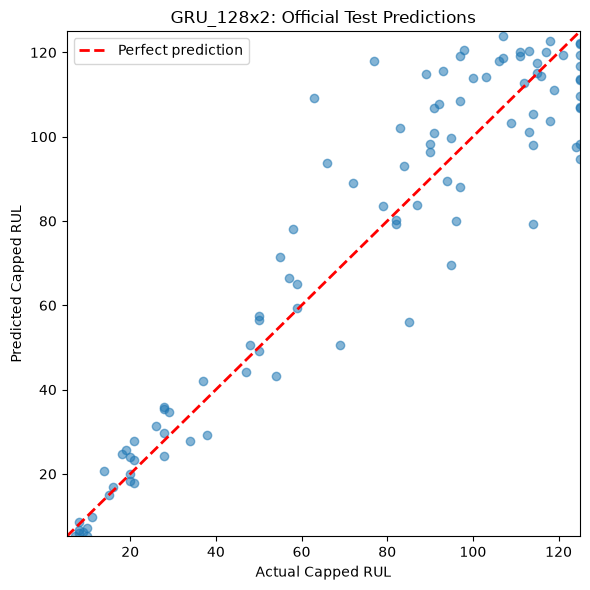

In [46]:
# Visualize the official-test predictions from the validation-selected model.
selected_test_pred = (
    gru_test_pred
    if selected_recurrent_model_name == best_gru_config["name"]
    else lstm_test_pred
)

plt.figure(figsize=(6, 6))
plt.scatter(
    y_test_actual,
    selected_test_pred,
    alpha=0.55,
)

plot_min = min(float(y_test_actual.min()), float(selected_test_pred.min()))
plot_max = max(float(y_test_actual.max()), float(selected_test_pred.max()))

plt.plot(
    [plot_min, plot_max],
    [plot_min, plot_max],
    "r--",
    linewidth=2,
    label="Perfect prediction",
)
plt.xlim(plot_min, plot_max)
plt.ylim(plot_min, plot_max)
plt.xlabel("Actual Capped RUL")
plt.ylabel("Predicted Capped RUL")
plt.title(f"{selected_recurrent_model_name}: Official Test Predictions")
plt.legend()
plt.tight_layout()
save_current_figure("selected_recurrent_official_test_actual_vs_predicted.png")
plt.show()


### Interpretation

The official test table is the final performance check after model development is complete. These results should be used for reporting, not for choosing between LSTM and GRU. Because the models were trained on capped RUL, the primary test metrics below use the same 0-125 target range for consistency.


In [47]:
official_test_predictions = pd.DataFrame({
    "unit_id": test_unit_ids,
    "actual_rul_raw": y_test_actual_raw,
    "actual_rul_capped": y_test_actual,
    "lstm_predicted_rul": lstm_test_pred,
    "gru_predicted_rul": gru_test_pred,
})

official_test_predictions["lstm_error"] = (
    official_test_predictions["lstm_predicted_rul"]
    - official_test_predictions["actual_rul_capped"]
)
official_test_predictions["gru_error"] = (
    official_test_predictions["gru_predicted_rul"]
    - official_test_predictions["actual_rul_capped"]
)

official_test_predictions.to_csv(
    PREDICTIONS_DIR / "official_lstm_gru_test_predictions.csv",
    index=False,
)
official_test_results.to_csv(
    REPORTS_DIR / "official_lstm_gru_test_results.csv",
    index=False,
)

# Save preprocessing information with each model so future inference can
# reproduce the same feature scaling used during training.
scaler_metadata = {
    "mean": full_sequence_scaler.mean_.tolist(),
    "scale": full_sequence_scaler.scale_.tolist(),
    "var": full_sequence_scaler.var_.tolist(),
    "n_features_in": int(full_sequence_scaler.n_features_in_),
}

torch.save(
    {
        "config": best_lstm_config,
        "epochs": best_lstm_epoch,
        "sequence_features": sequence_features,
        "sequence_length": SEQUENCE_LENGTH,
        "rul_cap": RUL_CAP,
        "scaler": scaler_metadata,
        "state_dict": final_lstm.state_dict(),
    },
    MODELS_DIR / "final_lstm_fd001.pt",
)

torch.save(
    {
        "config": best_gru_config,
        "epochs": best_gru_epoch,
        "sequence_features": sequence_features,
        "sequence_length": SEQUENCE_LENGTH,
        "rul_cap": RUL_CAP,
        "scaler": scaler_metadata,
        "state_dict": final_gru.state_dict(),
    },
    MODELS_DIR / "final_gru_fd001.pt",
)

display(official_test_predictions.head())


,unit_id,actual_rul_raw,actual_rul_capped,lstm_predicted_rul,gru_predicted_rul,lstm_error,gru_error
0,1,112.0,112.0,111.529861,112.820366,-0.470139,0.820366
1,2,98.0,98.0,114.545891,120.560303,16.545891,22.560303
2,3,69.0,69.0,45.465965,50.503830,-23.534035,-18.496170
3,4,82.0,82.0,79.440819,80.313400,-2.559181,-1.686600
4,5,91.0,91.0,103.471382,106.872375,12.471382,15.872375


# 12. Benchmark context and feature-engineering diagnosis


The following benchmark context is included to prevent overclaiming:

- A 2026 comparative study reported a simple single-layer LSTM FD001 RMSE of **14.93**, showing that simple recurrent models can be competitive but results depend strongly on preprocessing.
- A 2026 CNN–GRU study reported FD001 RMSE **13.1 ± 0.4** using a 30-cycle window, RUL cap 125, learning-rate scheduling, and repeated runs.
- A 2026 reproducibility study found that a reproduced Transformer-based method averaged **15.99 ± 1.39**, despite a lower originally reported single-run value. This shows why one online score should not be treated as an absolute standard.
- More advanced residual/attention methods report values near 11–12, but they use materially different architectures and representation learning.

### What likely limits the current model

1. **Single-run variance:** recurrent results can change with initialization.
2. **No learning-rate scheduler:** `ReduceLROnPlateau` may improve convergence.
3. **No convolutional front end:** a CNN can learn local cross-sensor patterns before the GRU.
4. **Single sequence scale:** multi-scale windows can capture both short and long degradation trends.
5. **RUL label assumption:** a fixed cap of 125 is reasonable but not universally optimal.
6. **Validation objective:** selecting by RMSE and selecting by asymmetric C-MAPSS score can choose different epochs/models.

### Recommended scope

For this course project, retain the current LSTM/GRU comparison and PEAS agent. Treat CNN–GRU, scheduler tuning, repeated seeds, and change-point labeling as future work rather than expanding the implementation indefinitely.

Sources:
- https://arxiv.org/abs/2604.27234
- https://doi.org/10.1155/er/7022062
- https://www.insticc.org/node/TechnicalProgram/data/2026/presentationDetails/150760
- https://link.springer.com/article/10.1007/s10791-026-10000-8

# 13. PEAS-based maintenance decision-support agent


## PEAS framing

- **Performance measure:** reduce late-failure risk while avoiding unnecessary early maintenance and respecting available maintenance capacity.
- **Environment:** the fleet of engines and the available maintenance slots.
- **Actuators:** schedule an engine, place it in the priority queue, or continue monitoring.
- **Sensors:** predicted RUL and disagreement between the LSTM and GRU predictions.

This is a **decision-support prototype**, not an autonomous maintenance system. The risk thresholds, disagreement threshold, and maintenance capacity are illustrative assumptions that would need to be defined with real operational and cost data before deployment.


In [48]:
# ---------------------------------------------------------
# 1. Use the recurrent model selected on validation data
# ---------------------------------------------------------

# The official test set is not used to choose the model for the agent.
if selected_recurrent_model_name == best_gru_config["name"]:
    selected_prediction = gru_test_pred
elif selected_recurrent_model_name == best_lstm_config["name"]:
    selected_prediction = lstm_test_pred
else:
    raise ValueError(
        "Validation-selected model does not match the finalized LSTM/GRU models."
    )

print("Validation-selected recurrent model:", selected_recurrent_model_name)


# ---------------------------------------------------------
# 2. Create one decision record for each test engine
# ---------------------------------------------------------

agent_input = pd.DataFrame({
    "unit_id": test_unit_ids,
    "predicted_rul": selected_prediction,

    # This is only a practical warning signal, not a calibrated confidence interval.
    "model_disagreement": np.abs(
        lstm_test_pred - gru_test_pred
    ),
})


# ---------------------------------------------------------
# 3. Convert predicted RUL into illustrative risk groups
# ---------------------------------------------------------

def classify_risk(predicted_rul: float) -> str:
    if predicted_rul <= 15:
        return "Critical"
    if predicted_rul <= 30:
        return "High"
    if predicted_rul <= 60:
        return "Medium"
    return "Low"


agent_input["risk_tier"] = (
    agent_input["predicted_rul"]
    .map(classify_risk)
)


# ---------------------------------------------------------
# 4. Flag predictions that deserve human review
# ---------------------------------------------------------

DISAGREEMENT_THRESHOLD = 10.0

agent_input["review_required"] = (
    agent_input["model_disagreement"] >= DISAGREEMENT_THRESHOLD
)


# ---------------------------------------------------------
# 5. Calculate maintenance urgency
# ---------------------------------------------------------

# Risk tier controls the broad ordering. Within a tier, lower RUL ranks first.
RISK_WEIGHTS = {
    "Critical": 300,
    "High": 200,
    "Medium": 100,
    "Low": 0,
}

agent_input["urgency_score"] = (
    agent_input["risk_tier"].map(RISK_WEIGHTS)
    + 100.0 / (agent_input["predicted_rul"] + 1.0)
)


# ---------------------------------------------------------
# 6. Rank the fleet from most urgent to least urgent
# ---------------------------------------------------------

maintenance_queue = (
    agent_input
    .sort_values(
        by=["urgency_score", "predicted_rul"],
        ascending=[False, True],
    )
    .reset_index(drop=True)
)

maintenance_queue["queue_position"] = (
    np.arange(1, len(maintenance_queue) + 1)
)


# ---------------------------------------------------------
# 7. Recommend a maintenance action
# ---------------------------------------------------------

# Maintenance action and model-review status are kept separate.
# A Critical engine can therefore be scheduled immediately AND flagged for review.
def recommend_action(risk_tier: str) -> str:
    if risk_tier == "Critical":
        return "Schedule immediately"
    if risk_tier == "High":
        return "Schedule soon"
    if risk_tier == "Medium":
        return "Monitor closely"
    return "Continue normal monitoring"


maintenance_queue["recommended_action"] = (
    maintenance_queue["risk_tier"]
    .map(recommend_action)
)

maintenance_queue["review_note"] = np.where(
    maintenance_queue["review_required"],
    "Review model disagreement",
    "",
)

display(maintenance_queue.head(20))

maintenance_queue.to_csv(
    REPORTS_DIR / "maintenance_queue.csv",
    index=False,
)


# ---------------------------------------------------------
# 8. Capacity analysis
# ---------------------------------------------------------

# Only High and Critical engines are eligible for maintenance.
# Extra capacity is left unused rather than maintaining lower-risk engines early.
eligible_queue = (
    maintenance_queue[
        maintenance_queue["risk_tier"]
        .isin(["Critical", "High"])
    ]
    .copy()
)

risk_counts = maintenance_queue["risk_tier"].value_counts()

total_critical = int(risk_counts.get("Critical", 0))
total_high = int(risk_counts.get("High", 0))
total_medium = int(risk_counts.get("Medium", 0))
total_low = int(risk_counts.get("Low", 0))
total_high_or_critical = total_critical + total_high

capacity_summary = []

for capacity in [5, 10, 15, 20, 30]:
    scheduled = eligible_queue.head(capacity)

    capacity_summary.append({
        "capacity": int(capacity),
        "total_critical": total_critical,
        "total_high": total_high,
        "total_medium": total_medium,
        "total_low": total_low,
        "total_high_or_critical": total_high_or_critical,
        "scheduled_engines": int(len(scheduled)),
        "unused_capacity": int(capacity - len(scheduled)),
        "critical_scheduled": int(
            (scheduled["risk_tier"] == "Critical").sum()
        ),
        "high_scheduled": int(
            (scheduled["risk_tier"] == "High").sum()
        ),
        "high_or_critical_scheduled": int(
            scheduled["risk_tier"]
            .isin(["Critical", "High"])
            .sum()
        ),
        "manual_reviews": int(
            scheduled["review_required"].sum()
        ),
        "maximum_scheduled_predicted_rul": (
            float(scheduled["predicted_rul"].max())
            if not scheduled.empty
            else np.nan
        ),
    })

capacity_summary = pd.DataFrame(capacity_summary)
display(capacity_summary)

capacity_summary.to_csv(
    REPORTS_DIR / "maintenance_capacity_analysis.csv",
    index=False,
)


Validation-selected recurrent model: GRU_128x2


,unit_id,predicted_rul,model_disagreement,risk_tier,review_required,urgency_score,queue_position,recommended_action,review_note
0,34,5.156353,3.110513,Critical,False,316.243383,1,Schedule immediately,
1,42,5.391364,5.833311,Critical,False,315.646113,2,Schedule immediately,
2,81,6.009723,1.531858,Critical,False,314.265899,3,Schedule immediately,
3,82,6.159860,5.139734,Critical,False,313.966753,4,Schedule immediately,
4,68,6.801624,5.306049,Critical,False,312.817844,5,Schedule immediately,
5,76,7.178317,3.644131,Critical,False,312.227456,6,Schedule immediately,
6,31,8.606690,3.033096,Critical,False,310.409412,7,Schedule immediately,
7,35,9.841004,1.290466,Critical,False,309.224237,8,Schedule immediately,
8,56,14.963373,0.750175,Critical,False,306.264340,9,Schedule immediately,
9,20,16.981056,1.039845,High,False,205.561409,10,Schedule soon,


,capacity,total_critical,total_high,total_medium,total_low,total_high_or_critical,scheduled_engines,unused_capacity,critical_scheduled,high_scheduled,high_or_critical_scheduled,manual_reviews,maximum_scheduled_predicted_rul
0,5,9,14,14,63,23,5,0,5,0,5,0,6.801624
1,10,9,14,14,63,23,10,0,9,1,10,0,16.981056
2,15,9,14,14,63,23,15,0,9,6,15,0,23.276764
3,20,9,14,14,63,23,20,0,9,11,20,0,27.777950
4,30,9,14,14,63,23,23,7,9,14,23,0,29.729036


### Interpretation

The queue prioritizes engines with the lowest predicted RUL, but it does not fill capacity just for the sake of using every slot. Only High- and Critical-risk engines are eligible for scheduling. If capacity is larger than the number of eligible engines, the remaining slots stay unused, which avoids servicing Medium- or Low-risk engines too early. A separate review flag highlights cases where the LSTM and GRU disagree enough to deserve human attention.


# 14. Final conclusions and limitations


### Main conclusions

- Sensor readings contain visible degradation patterns that can support RUL prediction.
- Backward-looking rolling features give tabular models useful recent-history information without using future cycles.
- LSTM and GRU use the raw 30-cycle sequence directly, so the temporal feature engineering is not repeated for those models.
- Model selection is based on held-out validation engines; the official test set is reserved for final reporting.
- The PEAS agent demonstrates how predicted RUL can be translated into a maintenance priority while avoiding unnecessary early maintenance.

### Limitations

- FD001 contains only one operating condition and one fault mode.
- The sensor channels are anonymized, which limits physical interpretation.
- The risk thresholds and maintenance-capacity values are illustrative project assumptions, not operational policies.
- Model disagreement is used only as a practical review flag; it is not a calibrated measure of uncertainty.
- Results are based on one primary random seed unless repeated-run analysis is added.
- Benchmark comparisons are approximate unless preprocessing, target definition, and evaluation protocol are identical.
